# TAE-IA · Module 6 · L14 — The Frequency World: FFT and Spectrograms

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L14 |
| **Track** | B — Audio |
| **Runtime** | CPU is sufficient — no GPU required |
| **Drive quota** | No large model downloads — no cleanup needed |

## Learning objectives

By the end of this notebook you will be able to:
1. Compute and plot the FFT power spectrum of a signal and identify peaks by frequency
2. Explain the difference between FFT (global) and STFT (windowed) representations
3. Generate STFT spectrograms with `librosa.stft()` and `librosa.display.specshow()`
4. Quantify how `n_fft` and `hop_length` control frequency vs. time resolution
5. Read a spectrogram and identify phonetic and musical events by their spectral shape

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('Setup complete. CPU runtime is sufficient for L14.')

Mounted at /content/drive
Setup complete. CPU runtime is sufficient for L14.


## Cell 1 — Install and import

In [2]:
!pip install librosa soundfile -q

import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import IPython.display as ipd

print(f'librosa {librosa.__version__}')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

librosa 0.11.0


## Cell 2 — Regenerate L13 audio signals

We regenerate the same three synthetic signals from L13 so this notebook is self-contained.

In [3]:
SR  = 22050
DUR = 3.0
N   = int(SR * DUR)
t   = np.linspace(0, DUR, N, endpoint=False)

# Voice-like: harmonic series + syllable envelope + silence gaps
f0 = 150.0
y_voice = sum((1.0 / k) * np.sin(2 * np.pi * f0 * k * t) for k in range(1, 8))
env = 0.5 + 0.5 * np.sin(2 * np.pi * 5 * t)
gap = np.ones(N)
gap[int(0.3*SR):int(0.5*SR)] = 0.0
gap[int(1.8*SR):int(2.0*SR)] = 0.0
y_voice = (y_voice * env * gap).astype(np.float32)
y_voice /= np.abs(y_voice).max() + 1e-8

# Music-like: A-major chord with tremolo
y_music = sum(np.sin(2 * np.pi * f * t) for f in [440.0, 554.37, 659.25])
y_music = (y_music * (1.0 + 0.3 * np.sin(2 * np.pi * 6 * t))).astype(np.float32)
y_music /= np.abs(y_music).max() + 1e-8

# Ambient-like: band-limited pink noise
rng   = np.random.default_rng(SEED)
white = rng.normal(0, 1, N).astype(np.float32)
fft_w = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, d=1.0/SR)
band  = ((freqs >= 200) & (freqs <= 4000)).astype(float)
with np.errstate(divide='ignore', invalid='ignore'):
    pink = np.where(freqs > 200, 200.0 / freqs, 1.0)
y_ambient = np.fft.irfft(fft_w * band * pink, n=N).astype(np.float32)
y_ambient /= np.abs(y_ambient).max() + 1e-8

AUDIO = {'voice': (y_voice, SR), 'music': (y_music, SR), 'ambient': (y_ambient, SR)}
COLOURS = {'voice': '#2C75FF', 'music': '#27ae60', 'ambient': '#8e44ad'}

print('Audio regenerated.')
for name, (y, sr) in AUDIO.items():
    print(f'  {name}: {len(y)} samples, {len(y)/sr:.1f}s')

Audio regenerated.
  voice: 66150 samples, 3.0s
  music: 66150 samples, 3.0s
  ambient: 66150 samples, 3.0s


---
## Section 2.1 — FFT Power Spectrum

The FFT takes the **entire signal** and produces a list of frequency components.

**Key concepts:**
- `np.fft.rfft(y)` — real FFT: returns `N//2 + 1` complex values (positive frequencies only)
- Magnitude: `np.abs(fft_result)` — how much of each frequency is present
- Frequency axis: `np.fft.rfftfreq(N, d=1/sr)` — maps each bin index to Hz
- Frequency resolution: `sr / N` Hz per bin — finer with more samples
- **Always apply a window function** (e.g., Hanning) before FFT to reduce *spectral leakage* — the smearing of energy from one frequency bin into adjacent bins.

Signal: 1s at 22050 Hz → 22050 samples
FFT output: 11026 bins, frequency resolution = 1.00 Hz/bin
Peak bin index: 440  → frequency: 440.0 Hz


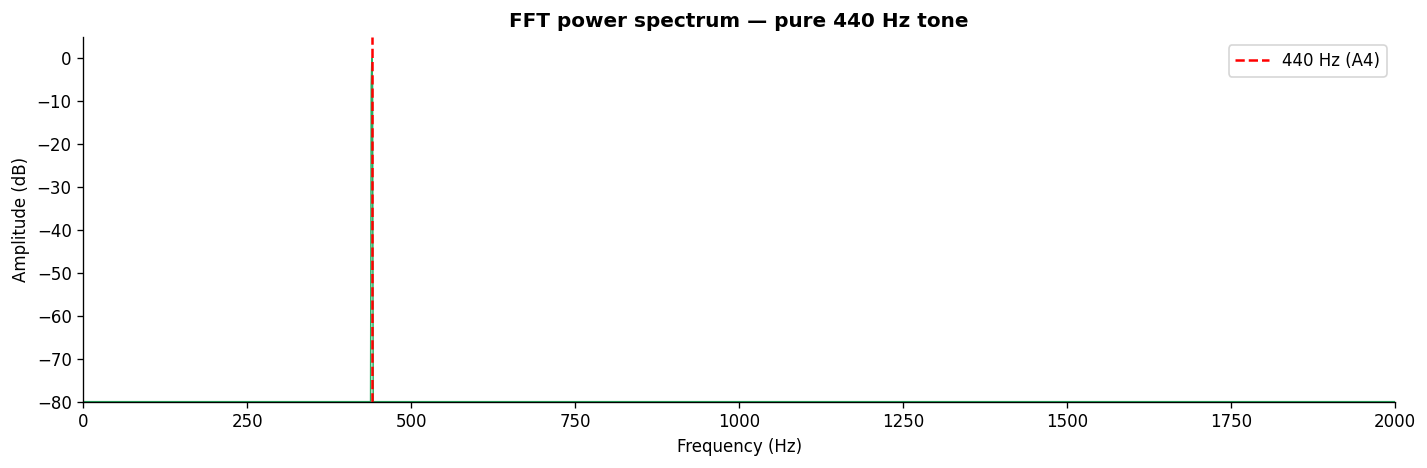

In [4]:
# First: intuition with a pure 440 Hz tone
t_1s  = np.linspace(0, 1.0, SR, endpoint=False)
y_440 = np.sin(2 * np.pi * 440 * t_1s).astype(np.float32)

window = np.hanning(len(y_440))
fft_   = np.fft.rfft(y_440 * window)
mag    = np.abs(fft_)
freq   = np.fft.rfftfreq(len(y_440), d=1.0/SR)
mag_db = librosa.amplitude_to_db(mag, ref=mag.max())

freq_res = SR / len(y_440)
print(f'Signal: 1s at {SR} Hz → {len(y_440)} samples')
print(f'FFT output: {len(mag)} bins, frequency resolution = {freq_res:.2f} Hz/bin')
print(f'Peak bin index: {np.argmax(mag)}  → frequency: {freq[np.argmax(mag)]:.1f} Hz')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freq, mag_db, color='#27ae60', linewidth=0.9)
ax.axvline(440, color='red', linewidth=1.5, linestyle='--', label='440 Hz (A4)')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude (dB)')
ax.set_title('FFT power spectrum — pure 440 Hz tone', fontweight='bold')
ax.set_xlim(0, 2000)
ax.set_ylim(-80, 5)
ax.legend()
plt.tight_layout()
plt.show()

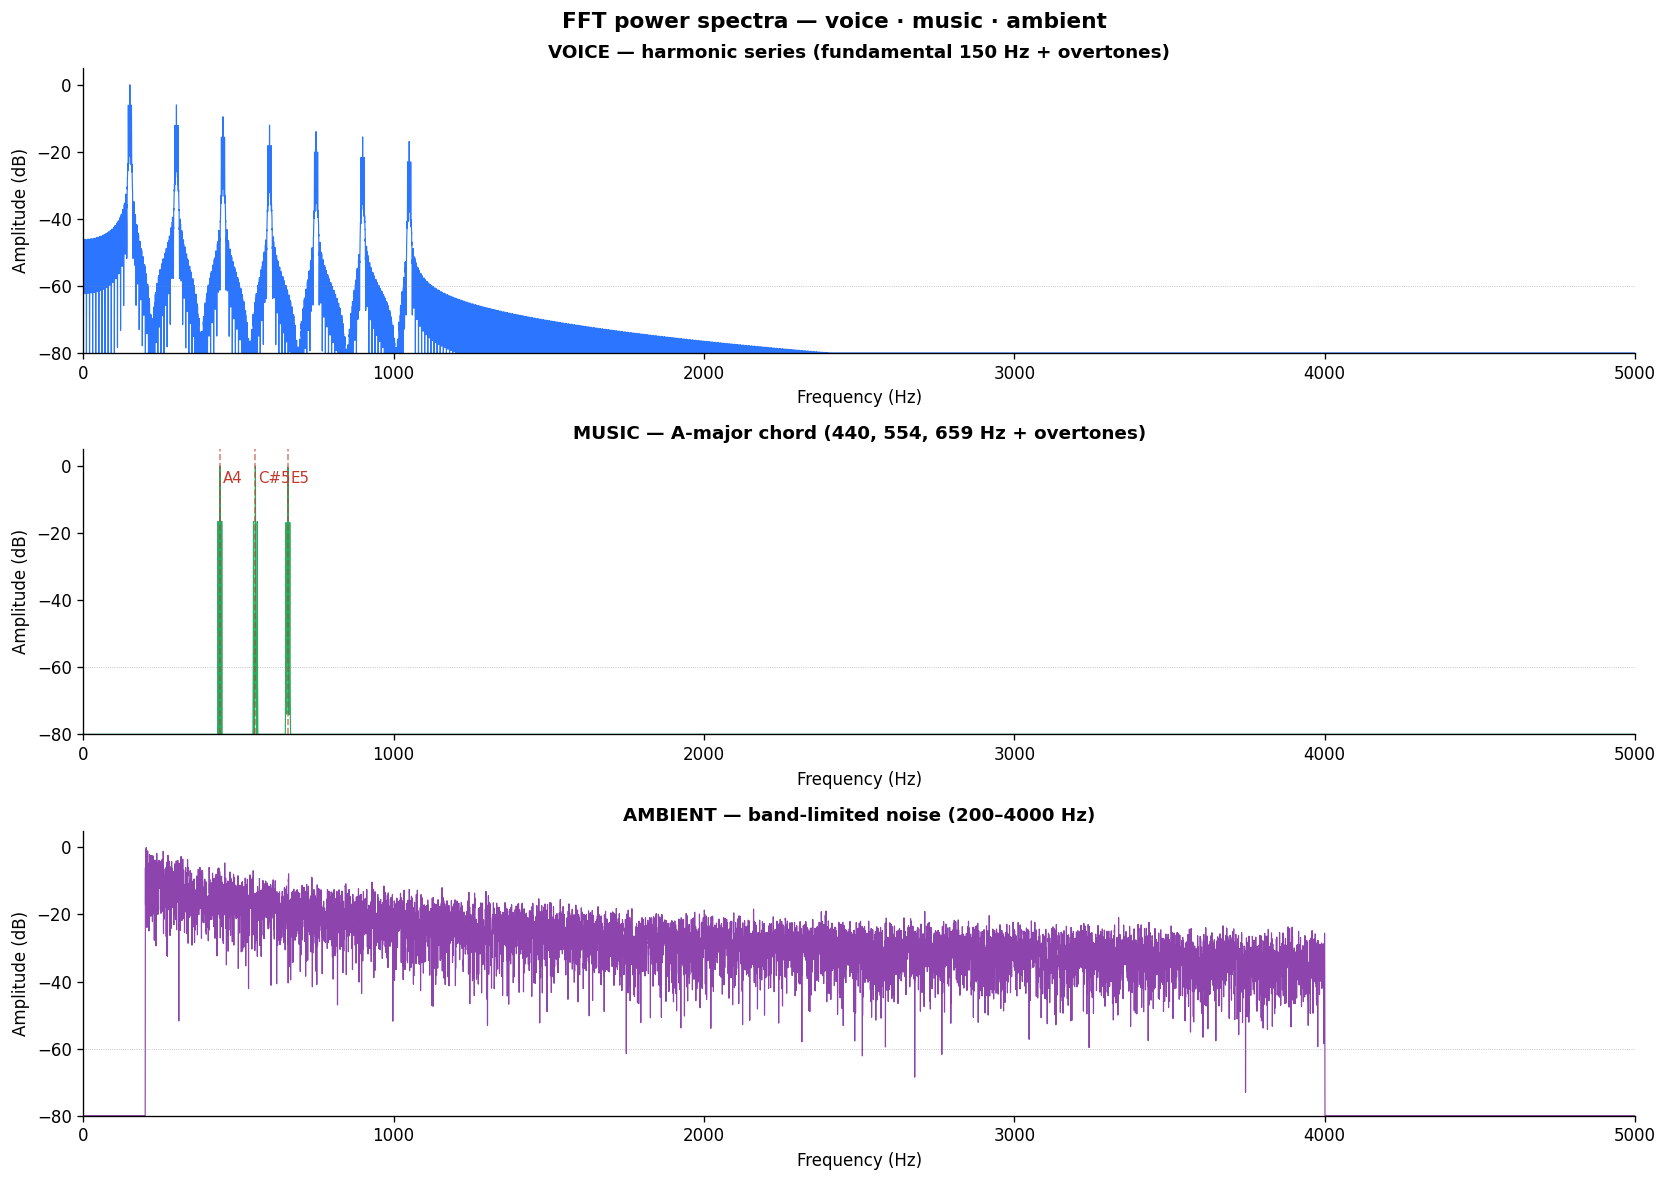

In [5]:
def plot_fft(y, sr, title, ax, color='#27ae60', xlim=5000):
    """Plot FFT power spectrum with Hanning window."""
    N      = len(y)
    window = np.hanning(N)
    fft_   = np.fft.rfft(y * window)
    mag    = np.abs(fft_)
    freq   = np.fft.rfftfreq(N, d=1.0/sr)
    mag_db = librosa.amplitude_to_db(mag, ref=mag.max())

    ax.plot(freq, mag_db, color=color, linewidth=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude (dB)')
    ax.set_xlim(0, xlim)
    ax.set_ylim(-80, 5)
    ax.axhline(-60, color='gray', linewidth=0.5, linestyle=':', alpha=0.6)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

plot_fft(y_voice,   SR, 'VOICE — harmonic series (fundamental 150 Hz + overtones)', axes[0], COLOURS['voice'])
plot_fft(y_music,   SR, 'MUSIC — A-major chord (440, 554, 659 Hz + overtones)',     axes[1], COLOURS['music'])
plot_fft(y_ambient, SR, 'AMBIENT — band-limited noise (200–4000 Hz)',                axes[2], COLOURS['ambient'])

# Annotate chord peaks
for f, label in [(440, 'A4'), (554, 'C#5'), (659, 'E5')]:
    axes[1].axvline(f, color='#c0392b', linewidth=1.0, linestyle='--', alpha=0.6)
    axes[1].text(f + 10, -5, label, color='#c0392b', fontsize=9)

plt.suptitle('FFT power spectra — voice · music · ambient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.2 — STFT Spectrograms

The STFT applies the FFT to **short overlapping windows** of the signal, producing a 2D matrix:
- Rows = frequency bins (0 to Nyquist)
- Columns = time frames
- Values = complex STFT coefficients; we take the magnitude and convert to dB

**Always convert to dB before plotting** — the raw linear magnitude compresses 99% of the dynamic range into a tiny bright band at the top.

In [6]:
# Compute STFT for all three signals with default parameters
N_FFT   = 2048
HOP_LEN = 512

spectrograms = {}
for name, (y, sr) in AUDIO.items():
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    spectrograms[name] = S_db

    freq_res = sr / N_FFT
    time_res = HOP_LEN / sr * 1000
    n_frames = D.shape[1]
    print(f'{name}: shape={D.shape}  freq_res={freq_res:.1f} Hz/bin  '
          f'time_res={time_res:.1f} ms/frame  n_frames={n_frames}')

voice: shape=(1025, 130)  freq_res=10.8 Hz/bin  time_res=23.2 ms/frame  n_frames=130
music: shape=(1025, 130)  freq_res=10.8 Hz/bin  time_res=23.2 ms/frame  n_frames=130
ambient: shape=(1025, 130)  freq_res=10.8 Hz/bin  time_res=23.2 ms/frame  n_frames=130


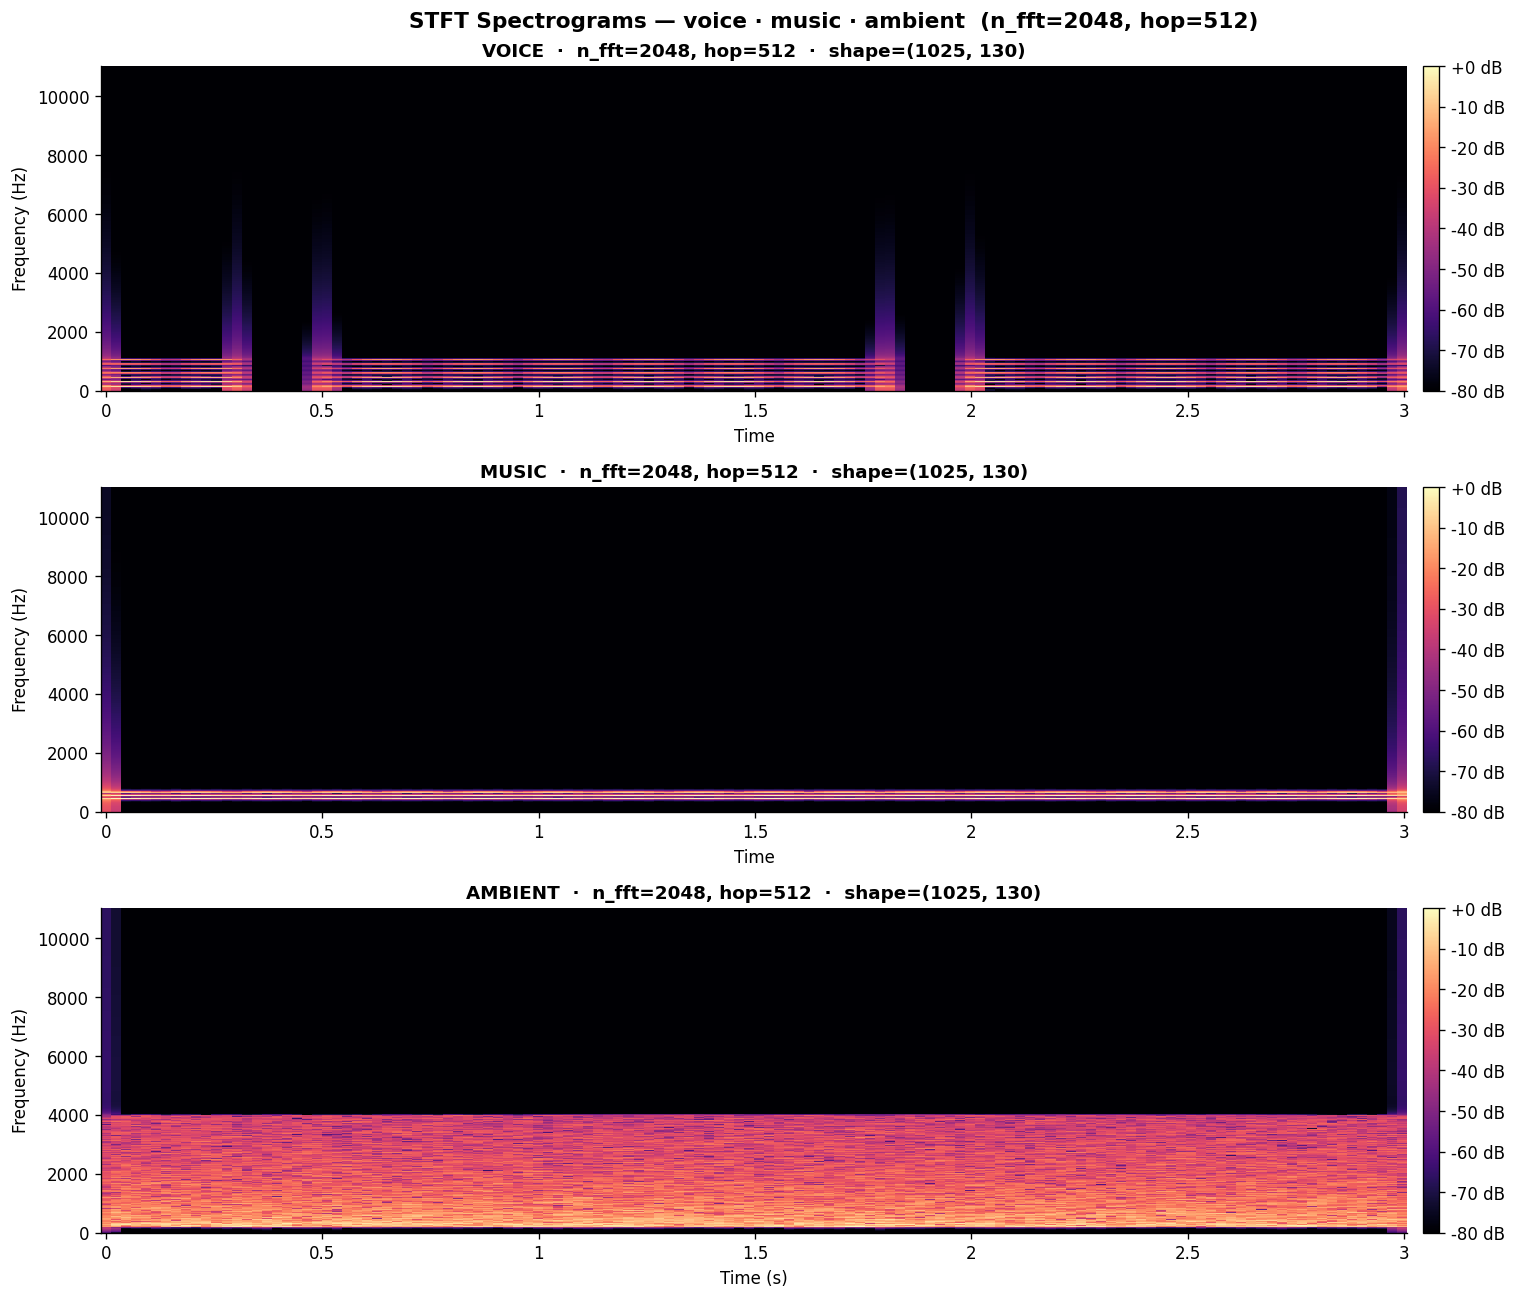

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

for ax, (name, (y, sr)) in zip(axes, AUDIO.items()):
    S_db = spectrograms[name]
    img  = librosa.display.specshow(
        S_db, sr=sr, hop_length=HOP_LEN,
        x_axis='time', y_axis='hz',
        ax=ax, cmap='magma'
    )
    ax.set_title(f'{name.upper()}  ·  n_fft={N_FFT}, hop={HOP_LEN}  '
                 f'·  shape={S_db.shape}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency (Hz)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('STFT Spectrograms — voice · music · ambient  (n_fft=2048, hop=512)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### What to look for in the spectrograms:

| Signal | Characteristic pattern | Reason |
|---|---|---|
| **Voice** | Horizontal bright bands (formants) with vertical dark gaps | Formants = vowel resonances; gaps = silence between syllables |
| **Music** | Horizontal stripes at fixed frequencies with harmonics above | Chord frequencies + their overtone series; tremolo = amplitude modulation |
| **Ambient** | Uniform texture — energy spread across frequencies and time | Noise has no dominant frequency or time structure |

---
## Section 2.3 — `n_fft` Sweep: Observing the Resolution Trade-off

The same voice clip rendered with three values of `n_fft`. The `hop_length` is fixed so time resolution only changes through the window length effect.

**What to expect:**
- `n_fft=256`: blurry frequency axis (86 Hz/bin), sharp time axis — good for transients
- `n_fft=1024`: balanced — the general-purpose default
- `n_fft=4096`: sharp frequency axis (5.4 Hz/bin), smeared time axis — good for pitch

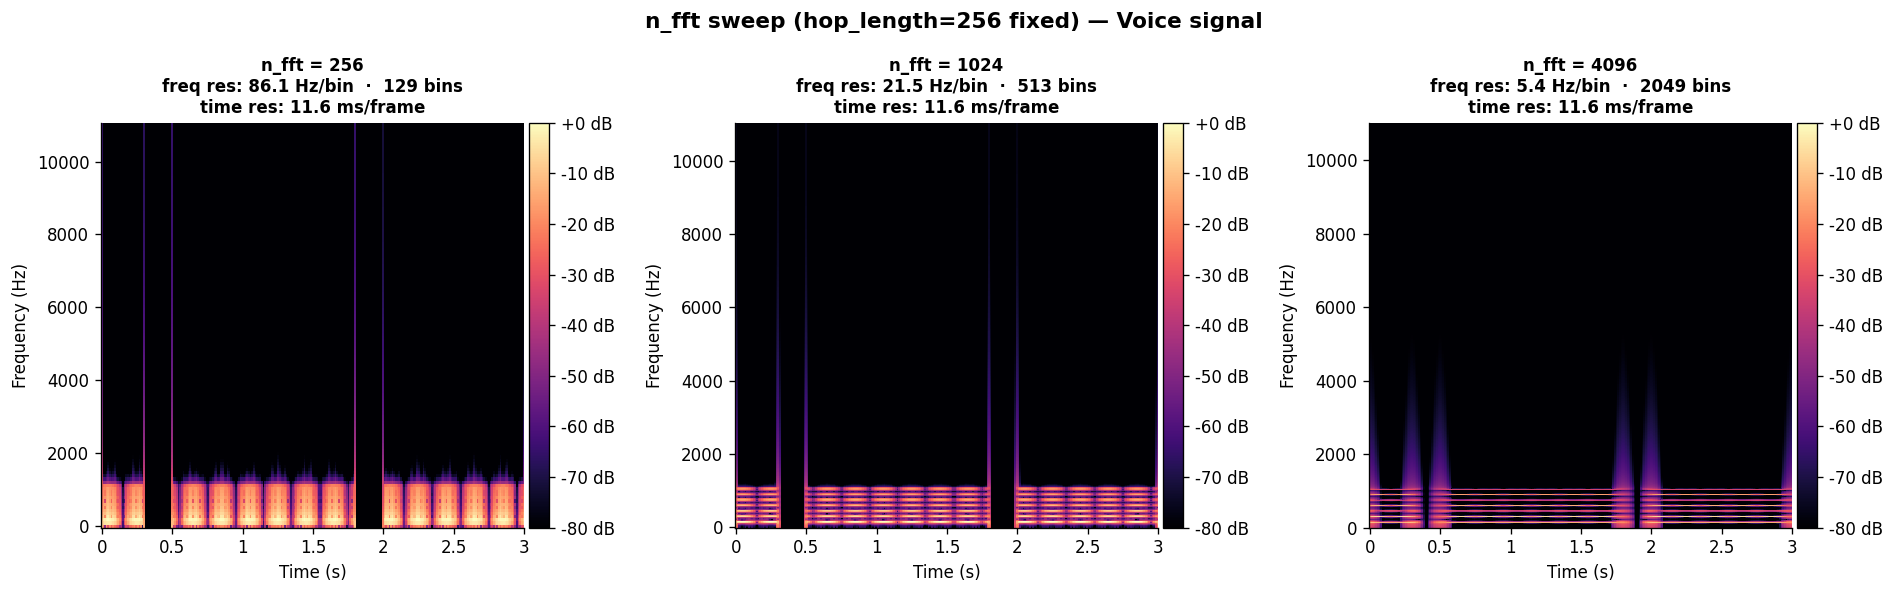

In [8]:
n_fft_values = [256, 1024, 4096]
HOP_FIXED    = 256
y_v, sr_v    = AUDIO['voice']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, n_fft in zip(axes, n_fft_values):
    D    = librosa.stft(y_v, n_fft=n_fft, hop_length=HOP_FIXED, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    freq_res = sr_v / n_fft
    time_res = HOP_FIXED / sr_v * 1000
    n_bins   = D.shape[0]

    img = librosa.display.specshow(
        S_db, sr=sr_v, hop_length=HOP_FIXED,
        x_axis='time', y_axis='hz',
        ax=ax, cmap='magma'
    )
    ax.set_title(
        f'n_fft = {n_fft}\n'
        f'freq res: {freq_res:.1f} Hz/bin  ·  {n_bins} bins\n'
        f'time res: {time_res:.1f} ms/frame',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

plt.suptitle(f'n_fft sweep (hop_length={HOP_FIXED} fixed) — Voice signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Resolution table for all common n_fft values at 22050 Hz
print(f'{"n_fft":>8}  {"freq res (Hz/bin)":>20}  {"#bins":>7}  {"window len (ms)":>18}')
print('-' * 62)
for n in [128, 256, 512, 1024, 2048, 4096]:
    freq_res = SR / n
    win_ms   = n / SR * 1000
    n_bins   = n // 2 + 1
    marker   = ' ← Whisper default' if n == 400 else (
               ' ← music default'   if n == 2048 else '')
    print(f'{n:>8}  {freq_res:>20.2f}  {n_bins:>7}  {win_ms:>18.1f}{marker}')

   n_fft     freq res (Hz/bin)    #bins     window len (ms)
--------------------------------------------------------------
     128                172.27       65                 5.8
     256                 86.13      129                11.6
     512                 43.07      257                23.2
    1024                 21.53      513                46.4
    2048                 10.77     1025                92.9 ← music default
    4096                  5.38     2049               185.8


---
## Section 2.4 — `hop_length` Sweep

Now fix `n_fft` and vary `hop_length`. This changes **how many time frames** appear in the spectrogram without changing frequency resolution.

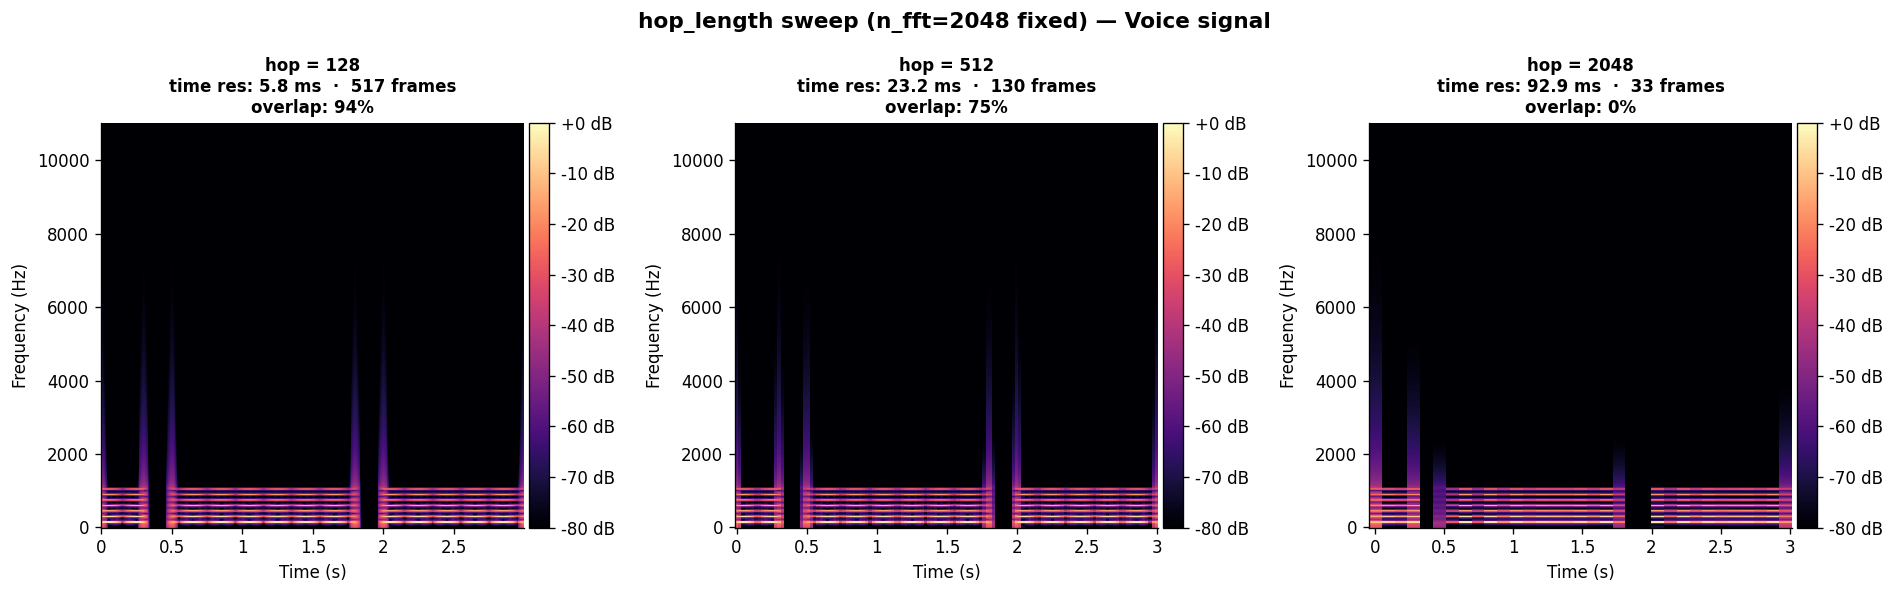

In [10]:
hop_values = [128, 512, 2048]
N_FFT_FIXED = 2048

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, hop in zip(axes, hop_values):
    D    = librosa.stft(y_v, n_fft=N_FFT_FIXED, hop_length=hop, window='hann')
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    time_res = hop / sr_v * 1000
    n_frames = D.shape[1]
    overlap  = (1 - hop / N_FFT_FIXED) * 100

    img = librosa.display.specshow(
        S_db, sr=sr_v, hop_length=hop,
        x_axis='time', y_axis='hz',
        ax=ax, cmap='magma'
    )
    ax.set_title(
        f'hop = {hop}\n'
        f'time res: {time_res:.1f} ms  ·  {n_frames} frames\n'
        f'overlap: {overlap:.0f}%',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (s)')
    plt.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.01)

plt.suptitle(f'hop_length sweep (n_fft={N_FFT_FIXED} fixed) — Voice signal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.5 — Waveform + Spectrogram Side-by-Side

Aligning the waveform and spectrogram in time makes it easier to see which waveform events correspond to which spectral patterns.

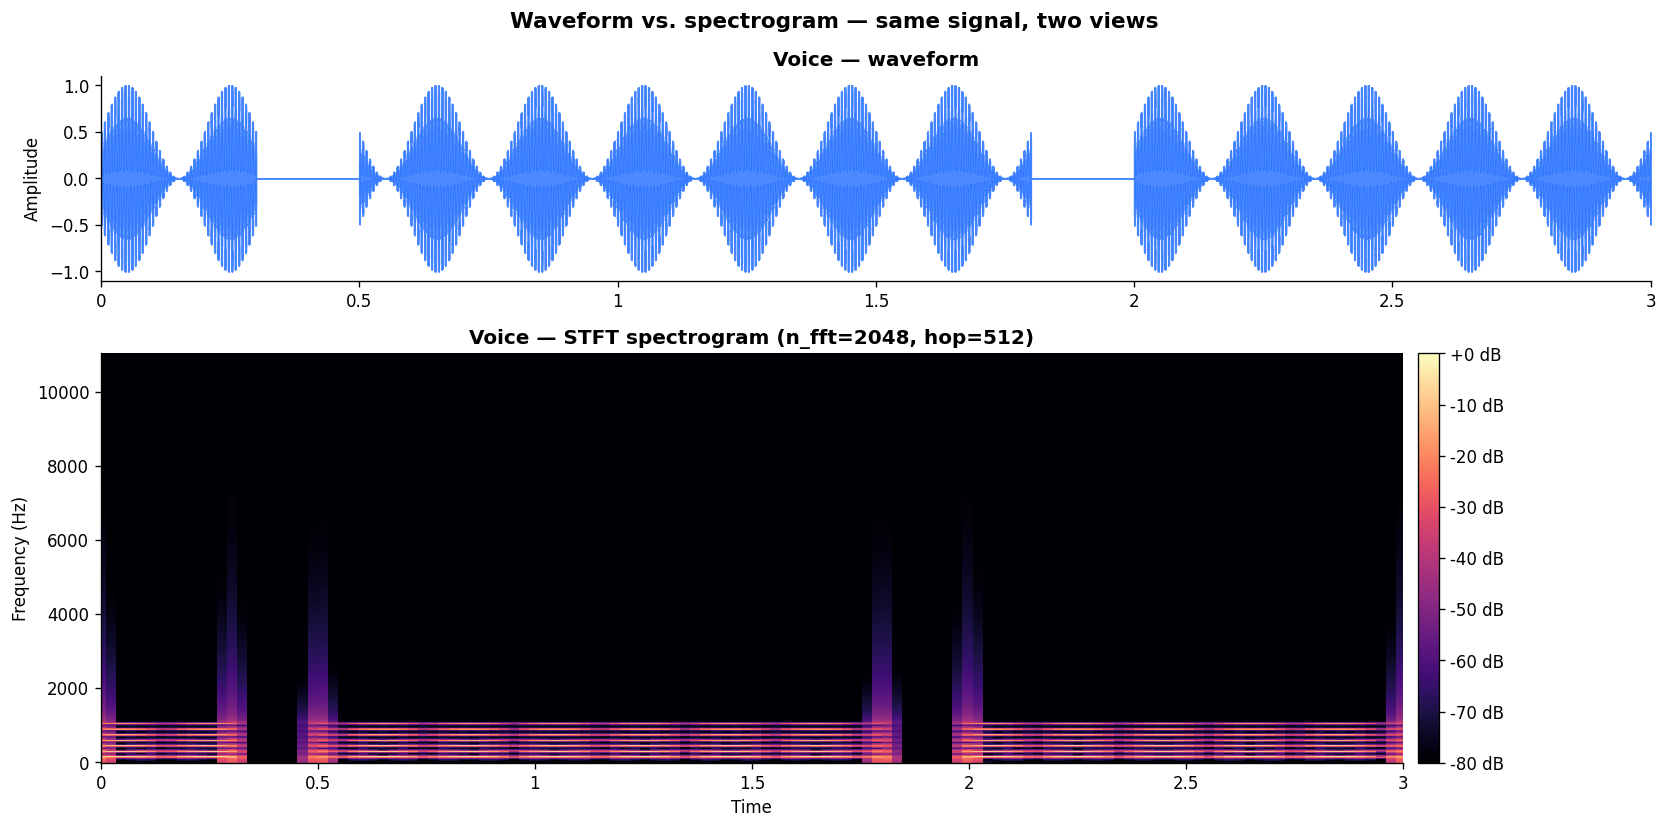


Observe: the silence gaps in the waveform (flat near zero) appear as dark vertical bands in the spectrogram.


In [11]:
fig, (ax_wave, ax_spec) = plt.subplots(2, 1, figsize=(14, 7),
                                         gridspec_kw={'height_ratios': [1, 2]})

# Waveform
librosa.display.waveshow(y_v, sr=SR, ax=ax_wave, color=COLOURS['voice'], alpha=0.85)
ax_wave.set_title('Voice — waveform', fontweight='bold')
ax_wave.set_xlabel('')
ax_wave.set_ylabel('Amplitude')

# Spectrogram
D    = librosa.stft(y_v, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img  = librosa.display.specshow(S_db, sr=SR, hop_length=512,
                                  x_axis='time', y_axis='hz',
                                  ax=ax_spec, cmap='magma')
ax_spec.set_title('Voice — STFT spectrogram (n_fft=2048, hop=512)', fontweight='bold')
ax_spec.set_ylabel('Frequency (Hz)')
plt.colorbar(img, ax=ax_spec, format='%+2.0f dB', pad=0.01)

# Align x-axis
ax_wave.set_xlim(0, DUR)
ax_spec.set_xlim(0, DUR)

plt.suptitle('Waveform vs. spectrogram — same signal, two views', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nObserve: the silence gaps in the waveform (flat near zero) appear as dark vertical'
      ' bands in the spectrogram.')

---
## Exercise 1 — Multi-tone identification

Generate a signal that contains **two different tones in sequence**: 330 Hz for the first 1.5 seconds, then 660 Hz for the last 1.5 seconds.

1. Compute the global FFT. Can you distinguish the two tones?
2. Compute the STFT spectrogram. Can you distinguish the two tones?
3. Explain in a markdown cell why the two representations give different results for this signal.

This exercise directly motivates the STFT: the FFT cannot answer "when did the pitch change?"

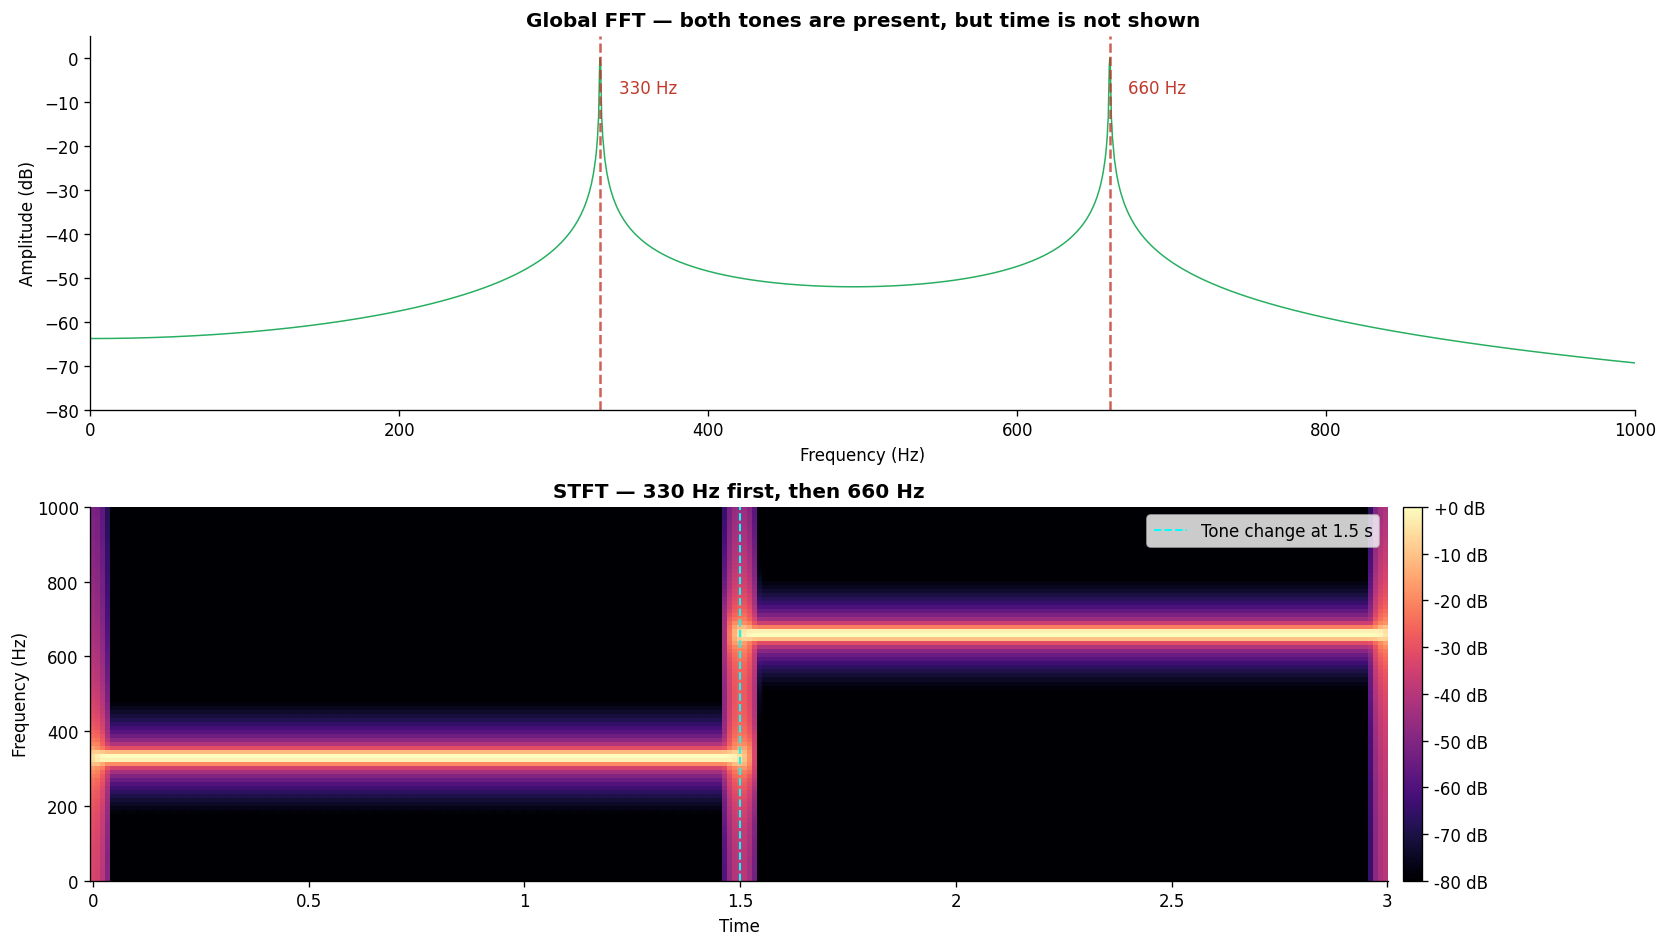

Strongest separated FFT peaks: 330.0 Hz, 660.0 Hz


In [14]:
# Two-tone signal: 330 Hz → 660 Hz
t_half = np.linspace(0, 1.5, int(SR * 1.5), endpoint=False)
y_low = np.sin(2 * np.pi * 330 * t_half).astype(np.float32)
y_high = np.sin(2 * np.pi * 660 * t_half).astype(np.float32)
y_two_tones = np.concatenate([y_low, y_high])

# Play the audio
ipd.display(ipd.Audio(y_two_tones, rate=SR))

# Compute the global FFT using a Hann window
window = np.hanning(len(y_two_tones))
fft_two = np.fft.rfft(y_two_tones * window)
mag_two = np.abs(fft_two)

freq_two = np.fft.rfftfreq(
    len(y_two_tones),
    d=1.0 / SR
)

mag_two_db = librosa.amplitude_to_db(
    mag_two,
    ref=np.max
)

# Find the two strongest separated peaks below 1000 Hz
peak_order = np.argsort(mag_two)[::-1]
peak_freqs = []

for idx in peak_order:
    candidate = freq_two[idx]

    if candidate > 1000:
        continue

    if all(abs(candidate - selected) > 20 for selected in peak_freqs):
        peak_freqs.append(candidate)

    if len(peak_freqs) == 2:
        break

# Compute the STFT
n_fft_ex1 = 2048
hop_ex1 = 256

D_two = librosa.stft(
    y_two_tones,
    n_fft=n_fft_ex1,
    hop_length=hop_ex1,
    window="hann"
)

S_two_db = librosa.amplitude_to_db(
    np.abs(D_two),
    ref=np.max
)

# Plot the FFT and STFT
fig, (ax_fft, ax_stft) = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

# Global FFT
ax_fft.plot(
    freq_two,
    mag_two_db,
    color="#27ae60",
    linewidth=0.9
)

for frequency in sorted(peak_freqs):
    ax_fft.axvline(
        frequency,
        color="#c0392b",
        linestyle="--",
        alpha=0.8
    )

    ax_fft.text(
        frequency + 12,
        -8,
        f"{frequency:.0f} Hz",
        color="#c0392b"
    )

ax_fft.set_title(
    "Global FFT — both tones are present, but time is not shown",
    fontweight="bold"
)
ax_fft.set_xlabel("Frequency (Hz)")
ax_fft.set_ylabel("Amplitude (dB)")
ax_fft.set_xlim(0, 1000)
ax_fft.set_ylim(-80, 5)

# STFT spectrogram
img = librosa.display.specshow(
    S_two_db,
    sr=SR,
    hop_length=hop_ex1,
    x_axis="time",
    y_axis="hz",
    ax=ax_stft,
    cmap="magma"
)

ax_stft.axvline(
    1.5,
    color="cyan",
    linestyle="--",
    linewidth=1.2,
    label="Tone change at 1.5 s"
)

ax_stft.set_title(
    "STFT — 330 Hz first, then 660 Hz",
    fontweight="bold"
)
ax_stft.set_ylabel("Frequency (Hz)")
ax_stft.set_ylim(0, 1000)
ax_stft.legend(loc="upper right")

plt.colorbar(
    img,
    ax=ax_stft,
    format="%+2.0f dB",
    pad=0.01
)

plt.tight_layout()
plt.show()

print(
    "Strongest separated FFT peaks:",
    ", ".join(
        f"{frequency:.1f} Hz"
        for frequency in sorted(peak_freqs)
    )
)

**Exercise 1 — Answer:**

[YOUR ANSWER — explain why FFT cannot separate the two tones in time, but STFT can]

The global FFT shows strong peaks near 330 Hz and 660 Hz, so it can identify both tones. However, it analyzes the complete three-second signal as one block, so it does not show when each tone occurs. The STFT analyzes short windows and keeps their time positions. Therefore, its spectrogram shows 330 Hz from 0 to 1.5 seconds and 660 Hz from 1.5 to 3 seconds.

---
## Exercise 2 — Optimal parameters for a speech task

Whisper uses `n_fft=400` and `hop_length=160` at 16000 Hz.

1. Compute the frequency resolution and time resolution for Whisper's parameters
2. Resampled `y_voice` to 16000 Hz and plot its spectrogram using Whisper's exact parameters
3. In a markdown cell: explain why Whisper chose a relatively small `n_fft=400` (25 ms window) instead of the music default of 2048 (~93 ms). What acoustic property of speech makes 25 ms appropriate?

Whisper STFT parameters:
  n_fft=400  hop=160  sr=16000
  Frequency resolution : 40.0 Hz/bin
  Time resolution      : 10.0 ms/frame
  Window duration      : 25.0 ms


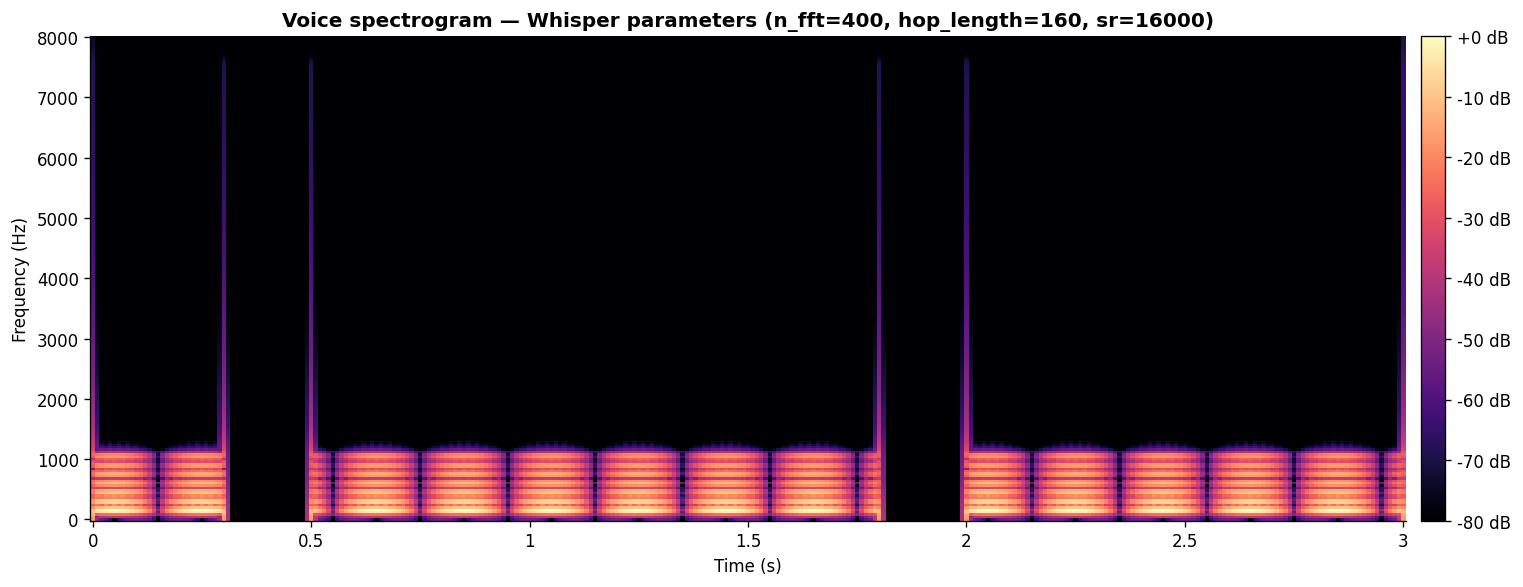

Resampled signal: 48000 samples, 3.0 s
STFT shape: (201, 301)


In [15]:
# Whisper parameters
N_FFT_WHISPER = 400
HOP_WHISPER = 160
SR_WHISPER = 16000

# Calculate resolutions
freq_res = SR_WHISPER / N_FFT_WHISPER
time_res = HOP_WHISPER / SR_WHISPER * 1000
window_duration = N_FFT_WHISPER / SR_WHISPER * 1000

print("Whisper STFT parameters:")
print(
    f"  n_fft={N_FFT_WHISPER}  "
    f"hop={HOP_WHISPER}  "
    f"sr={SR_WHISPER}"
)
print(f"  Frequency resolution : {freq_res:.1f} Hz/bin")
print(f"  Time resolution      : {time_res:.1f} ms/frame")
print(f"  Window duration      : {window_duration:.1f} ms")

# Resample the voice signal from 22050 Hz to 16000 Hz
y_voice_16k = librosa.resample(
    y_voice,
    orig_sr=SR,
    target_sr=SR_WHISPER
)

# Compute the STFT using Whisper's parameters
D_whisper = librosa.stft(
    y_voice_16k,
    n_fft=N_FFT_WHISPER,
    hop_length=HOP_WHISPER,
    win_length=N_FFT_WHISPER,
    window="hann"
)

S_whisper_db = librosa.amplitude_to_db(
    np.abs(D_whisper),
    ref=np.max
)

# Plot the spectrogram
fig, ax = plt.subplots(figsize=(14, 5))

img = librosa.display.specshow(
    S_whisper_db,
    sr=SR_WHISPER,
    hop_length=HOP_WHISPER,
    x_axis="time",
    y_axis="hz",
    ax=ax,
    cmap="magma"
)

ax.set_title(
    "Voice spectrogram — Whisper parameters "
    "(n_fft=400, hop_length=160, sr=16000)",
    fontweight="bold"
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")

plt.colorbar(
    img,
    ax=ax,
    format="%+2.0f dB",
    pad=0.01
)

plt.tight_layout()
plt.show()

print(
    f"Resampled signal: {len(y_voice_16k)} samples, "
    f"{len(y_voice_16k) / SR_WHISPER:.1f} s"
)
print(f"STFT shape: {D_whisper.shape}")

**Exercise 2 — Answer:**

[YOUR ANSWER — why 25 ms window for speech recognition?]

Speech changes quickly because each word contains short phonemes, especially consonants. A 25 ms window is short enough to treat a small part of speech as almost stable, while it still contains enough samples to show useful frequency information. A 2048-sample window at 22050 Hz lasts about 93 ms and can mix several short speech events together. Whisper uses the 25 ms window and a 10 ms hop to follow these changes more clearly.

---
## Part 4 — Critical Analysis

Answer all four questions with real outputs from the cells above.

### Q1 — FFT and ZCR

From your Section 2.1 FFT spectra: which of the three signals has the highest ZCR (recall from L13)? Does the FFT spectrum visually confirm why? Explain the connection between ZCR and spectral flatness in 2–3 sentences.

**[YOUR ANSWER]**

The ambient signal should have the highest ZCR because its noise contains energy across a broad range, from about 200 to 4000 Hz. Its FFT is more spread out and flatter than the clear harmonic peaks of voice and music, so the waveform changes direction and crosses zero more often. In general, a flatter and broader spectrum often produces a higher ZCR than a tonal spectrum.

---

### Q2 — Spectrogram patterns

In your Section 2.2 spectrograms, identify **one feature** that appears in the voice spectrogram but not in the ambient spectrogram. Name:
- The approximate frequency range it occupies (Hz)
- What acoustic event it represents
- Whether you could detect that event from the waveform alone

**[YOUR ANSWER]**

The voice spectrogram has clear horizontal harmonic bands from about 150 Hz to 1050 Hz, while the ambient signal has a more continuous texture. These bands represent the fundamental voice-like frequency and its harmonics during voiced sections. The waveform can suggest that the sound is periodic, but it cannot show the separate harmonic frequencies as clearly as the spectrogram.

---

### Q3 — n_fft trade-off for speech recognition

From your Section 2.3 n_fft sweep: comparing `n_fft=256` vs. `n_fft=4096` for the voice signal — for a Whisper-like speech recognition task, which would you choose and why?

Consider: speech phonemes have typical durations of 50–200 ms; the fundamental frequency of speech is 80–300 Hz; consonants (stops, fricatives) have durations of 5–50 ms.

**[YOUR ANSWER]** *(~4 sentences)*

I would choose `n_fft=256` between these two options because its window is about 11.6 ms and can follow short consonants and phoneme changes. Its frequency resolution is only about 86 Hz per bin, so it is less precise for pitch. In contrast, `n_fft=4096` gives excellent frequency resolution but uses a window of about 185.8 ms, which can blur several phonemes together. In practice, a value near Whisper's 400 samples gives a better balance for speech.

---

### Q4 — Bridge to AI: spectrograms as images

Explain in 3 sentences:
1. Why a CNN trained on natural images (CIFAR-10) could in principle classify spectrograms without retraining from scratch
2. What assumption this transfer requires
3. One specific scenario where this assumption would break down

**[YOUR ANSWER]**

A CNN trained on natural images can reuse early filters that detect local edges, lines, and textures because spectrograms also contain these visual patterns. This transfer assumes that useful local patterns in natural images are similar enough to time-frequency patterns and that the spectrograms use a consistent scale and orientation. The assumption can fail when the task depends on audio-specific meaning, such as recognizing the same melody after a pitch shift, because an image CNN may treat the shifted pattern as a different object.

---

---
## Submission Checklist

Before saving and submitting:

- [X] Cell 0 ran without errors (Drive mounted)
- [X] Section 2.1: FFT spectra plotted for all 3 audio types with peaks labelled
- [X] Section 2.2: STFT spectrograms plotted for all 3 audio types
- [X] Section 2.3: n_fft sweep (256 / 1024 / 4096) plotted side-by-side
- [X] Section 2.4: hop_length sweep plotted
- [X] Section 2.5: waveform + spectrogram aligned side-by-side
- [X] Exercise 1 complete (two-tone FFT vs. STFT + written explanation)
- [X] Exercise 2 complete (Whisper parameters + written explanation)
- [X] Critical Analysis Q1–Q4 answered (no `[YOUR ANSWER]` remaining)
- [X] Notebook saved to Drive

**No Drive cleanup needed after L14** — no large models were downloaded.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L14*  
*Track B — Audio | Next: L15 — Mel, MFCC, and the Language Models Understand*